# Halo lensing: truncated NFW & Hernquist profiles, weak and strong lensing

Dark-matter halos gravitationally lens the light of background sources. Two
regimes matter observationally:

* **Weak lensing** — the coherent, few-percent tangential distortion of the
  shapes of many faint background galaxies around a foreground halo. Averaged
  in radial bins it measures the *excess surface mass density* $\Delta\Sigma(R)$,
  the workhorse of galaxy–galaxy lensing and cluster mass calibration.
* **Strong lensing** — where the surface density exceeds a critical value the
  mapping from source to image plane becomes multivalued: multiple images,
  giant arcs, Einstein rings. The relevant scales are the *Einstein radius* and
  the *critical curves*.

Both regimes are controlled by the same projected quantities of the halo mass
profile. This notebook builds them for four density profiles, in pure
[JAX](https://docs.jax.dev) so that every observable is automatically
differentiable with respect to mass, concentration and cosmology.

### What is implemented

| ingredient | module | key functions |
|---|---|---|
| density profiles $\rho(r)$, projections $\Sigma,\bar\Sigma,\Delta\Sigma$ | [`hod_mod/core/lensing_profiles.py`](../hod_mod/core/lensing_profiles.py) | `tnfw_*`, `bmo_*`, `hernquist_*` |
| $\Sigma_{\rm crit}$, $\kappa$, $\gamma_t$, mis-centering, 2-halo, strong lensing | [`hod_mod/observables/lensing.py`](../hod_mod/observables/lensing.py) | `sigma_crit`, `ClusterLensingPrediction`, `solve_einstein_radius` |
| infinite-NFW reference | [`hod_mod/core/halo_profiles.py`](../hod_mod/core/halo_profiles.py) | `nfw_rho`, `nfw_sigma`, `nfw_delta_sigma` |

The feature set mirrors the model of the HSC final-year cluster-catalog paper,
[Oguri et al. 2026, PASJ 78, 416 (arXiv:2512.13954)](https://arxiv.org/abs/2512.13954),
and its companion code
[`massarin/halo_lensing`](https://github.com/massarin/halo_lensing); the
strong-lensing block is an addition. Validation against that reference and the
governing equations live in
[`tests/test_lensing_profiles.py`](../tests/test_lensing_profiles.py),
[`tests/test_lensing_observables.py`](../tests/test_lensing_observables.py) and
[`docs/lensing.rst`](../docs/lensing.rst).

### Conventions

All lengths are **comoving** $\mathrm{Mpc}/h$, masses $M_\odot/h$, surface
densities comoving $h\,M_\odot/\mathrm{Mpc}^2$ (a factor $10^{-12}$ converts to
the customary $h\,M_\odot/\mathrm{pc}^2$ used in plots), angles in arcsec. We
enable 64-bit floats: the analytic projections cancel near $R=r_s$ and lose
precision in the JAX default float32.


In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # x64 for sub-percent small-radius accuracy

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from hod_mod.core.power_spectrum import LinearPowerSpectrum, eisenstein_hu_pk_phys
from hod_mod.core.halo_mass_function import make_hmf
from hod_mod.core.halo_profiles import nfw_rho, nfw_sigma, nfw_delta_sigma
from hod_mod.core.lensing_profiles import (
    tnfw_rho, tnfw_sigma, tnfw_delta_sigma, tnfw_mass,
    bmo_rho, bmo_sigma, bmo_delta_sigma, bmo_mass_total,
    hernquist_rho, hernquist_sigma, hernquist_delta_sigma, hernquist_mean_sigma,
    nfw_params_from_mass)
from hod_mod.observables.lensing import (
    sigma_crit, inv_sigma_crit, ClusterLensingPrediction,
    solve_einstein_radius, radial_critical_radius)

theta = LinearPowerSpectrum.default_cosmology()
theta["sigma8"] = 0.81           # sigma8-normalised linear P(k) for the 2-halo term
PC2 = 1e-12                      # Msun h/Mpc^2 -> Msun h/pc^2
theta

{'h': 0.6736,
 'Omega_b': 0.0493,
 'Omega_cdm': 0.2607,
 'Omega_m': 0.31,
 'n_s': 0.9649,
 'ln10^{10}A_s': 3.044,
 'w0': -1.0,
 'wa': 0.0,
 'sigma8': 0.81}

## 0. Lensing in one screen

A thin lens is fully described by its **surface mass density**
$\Sigma(\mathbf R)$ — the 3-D density integrated along the line of sight. The
projection of a spherical profile is the **Abel transform**

$$
\Sigma(R) \;=\; \int_{-\infty}^{\infty}\!\rho\!\left(\sqrt{R^2+\ell^2}\right)\,\mathrm d\ell
        \;=\; 2\int_{0}^{\infty}\!\rho\!\left(\sqrt{R^2+\ell^2}\right)\,\mathrm d\ell ,
$$

with $R$ the projected (cylindrical) radius. Two derived quantities appear
everywhere below:

$$
\bar\Sigma(<R) \;=\; \frac{2}{R^2}\int_0^R \Sigma(R')\,R'\,\mathrm dR'
             \;=\; \frac{M_{\rm 2D}(<R)}{\pi R^2},
\qquad
\Delta\Sigma(R) \;\equiv\; \bar\Sigma(<R) - \Sigma(R).
$$

$\bar\Sigma$ is the mean surface density inside $R$ (equivalently the projected
mass in a cylinder), and $\Delta\Sigma$ is the **excess surface density**.

The strength of a lens is set relative to the **critical surface density**

$$
\Sigma_{\rm crit} \;=\; \frac{c^2}{4\pi G}\,\frac{D_s}{D_l\,D_{ls}},
$$

with $D_l, D_s, D_{ls}$ the (angular-diameter) observer–lens, observer–source
and lens–source distances. The dimensionless **convergence** and **tangential
shear** are then

$$
\kappa(R)=\frac{\Sigma(R)}{\Sigma_{\rm crit}},\qquad
\gamma_t(R)=\frac{\Delta\Sigma(R)}{\Sigma_{\rm crit}}=\bar\kappa(<R)-\kappa(R).
$$

The last identity is why $\Delta\Sigma$ *is* the galaxy–galaxy lensing
observable: the azimuthally averaged tangential shear of background galaxies
measures $\gamma_t$, hence $\Delta\Sigma$ up to the geometric factor
$\Sigma_{\rm crit}$. (References: Wright & Brainerd 2000, ApJ 534, 34;
Bartelmann & Schneider 2001, Phys. Rep. 340, 291.)


## 1. The profile family

We compare four spherical density profiles, all set up for the same
cluster-scale halo: $M_{\rm vir}=10^{14}\,M_\odot/h$ at $z_l=0.3$, with the
concentration $c$ from Duffy et al. 2008 and the virial mass definition
(Bryan & Norman 1998). The truncated profiles share the NFW characteristic
density $\rho_s$ and scale radius $r_s$; only the outer behaviour differs.

Writing $x=r/r_s$:

| profile | $\rho(r)$ | outer slope | code |
|---|---|---|---|
| **NFW** (Navarro, Frenk & White 1997) | $\dfrac{\rho_s}{x(1+x)^2}$ | $r^{-3}$ | [`nfw_rho`](../hod_mod/core/halo_profiles.py) |
| **TJ** — sharply truncated (Takada & Jain 2003) | $\dfrac{\rho_s}{x(1+x)^2}\,\Theta(c_t\,r_s-r)$ | cut at $r=c_t r_s$ | [`tnfw_rho`](../hod_mod/core/lensing_profiles.py) |
| **BMO** — smoothly truncated (Baltz, Marshall & Oguri 2009) | $\dfrac{\rho_s}{x(1+x)^2}\left(\dfrac{\tau^2}{\tau^2+x^2}\right)^{2}$ | $r^{-7}$ beyond $r_t=\tau r_s$ | [`bmo_rho`](../hod_mod/core/lensing_profiles.py) |
| **Hernquist** (Hernquist 1990) | $\dfrac{M\,r_b}{2\pi\,r\,(r+r_b)^3}$ | $r^{-4}$ | [`hernquist_rho`](../hod_mod/core/lensing_profiles.py) |

**Why truncate?** The NFW profile has a divergent total mass
($\int\rho\,r^2\mathrm dr\propto\ln r$) and an infinitely extended
$\Sigma(R)$, which is both unphysical (halos end where the 2-halo term takes
over) and awkward numerically (the Fourier transform of NFW only converges
because it is implicitly cut at $r=c\,r_s$). The **TJ** profile imposes a hard
cut at the virial radius; the **BMO** profile replaces it with a smooth
$[\,r_t^2/(r^2+r_t^2)\,]^2$ roll-off (here $r_t=2.5\,r_{\rm vir}$, i.e.
$\tau=2.5\,c$), which keeps derivatives continuous and has a closed-form
Fourier transform. The **Hernquist** profile is the classic model for the
stellar component of an elliptical galaxy (used in the composite lens of
§4); here it is scaled up only for visual comparison.

The mass/scale conversion $(M_\Delta, c)\to(\rho_s, r_s)$ for a given overdensity
definition is [`nfw_params_from_mass`](../hod_mod/core/lensing_profiles.py); the
$c(M,z)$ relation and pipeline are wrapped by
[`ClusterLensingPrediction`](../hod_mod/observables/lensing.py).


In [2]:
m_h, z_l, z_s = 1e14, 0.3, 1.0

clp_bmo  = ClusterLensingPrediction(profile="bmo",  mdef="vir", cm_relation="duffy08", tau_v=2.5)
clp_tj   = ClusterLensingPrediction(profile="tnfw", mdef="vir", cm_relation="duffy08", tau_v=1.0)
clp_nfw  = ClusterLensingPrediction(profile="nfw",  mdef="vir", cm_relation="duffy08")

c = float(clp_bmo.concentration(jnp.array([m_h]), z_l, theta)[0])
rho_s, r_s, r_vir = (float(v[0]) for v in
                     nfw_params_from_mass(jnp.array([m_h]), jnp.array([c]), z_l, theta, "vir"))
tau = 2.5 * c
print(f"c_vir = {c:.2f},  r_s = {r_s:.3f} Mpc/h,  r_vir = {r_vir:.3f} Mpc/h,  tau = {tau:.1f}")
print(f"BMO total mass / M_vir = {float(bmo_mass_total(rho_s, r_s, tau))/m_h:.3f}")
m_hern, rb_hern = m_h, 0.551 * r_vir / 4     # illustrative Hernquist with r_e ~ r_vir/4

c_vir = 4.75,  r_s = 0.217 Mpc/h,  r_vir = 1.029 Mpc/h,  tau = 11.9
BMO total mass / M_vir = 1.390


The 3-D densities $\rho(r)$ (left) and $r^2\rho(r)$ (right, which
integrates to the enclosed mass per $\mathrm d\ln r$) make the truncation
explicit: NFW and TJ overlap until the hard cut at $r_{\rm vir}$ (dotted),
while BMO peels away smoothly around $r_t=2.5\,r_{\rm vir}$ (dashed).

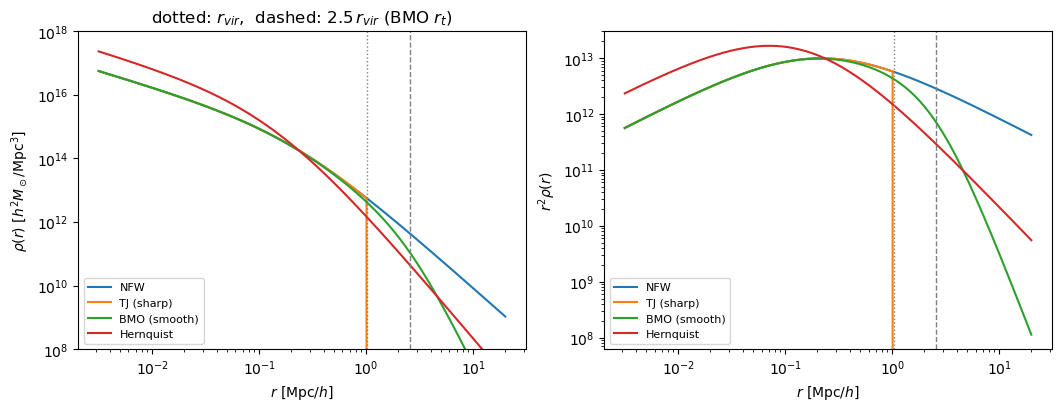

In [3]:
r = jnp.logspace(-2.5, 1.3, 300)
rho = {"NFW":       nfw_rho(r, rho_s, r_s),
       "TJ (sharp)": tnfw_rho(r, rho_s, r_s, c),
       "BMO (smooth)": bmo_rho(r, rho_s, r_s, tau),
       "Hernquist": hernquist_rho(r, m_hern, rb_hern)}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)
for name, y in rho.items():
    axes[0].loglog(r, y, label=name)
    axes[1].loglog(r, r**2 * y, label=name)
for ax, ylab in zip(axes, [r"$\rho(r)$ [$h^2 M_\odot/{\rm Mpc}^3$]",
                           r"$r^2\rho(r)$"]):
    ax.axvline(r_vir, color="gray", ls=":", lw=1)
    ax.axvline(2.5 * r_vir, color="gray", ls="--", lw=1)
    ax.set_xlabel(r"$r$ [Mpc/$h$]"); ax.set_ylabel(ylab); ax.legend(fontsize=8)
axes[0].set_ylim(1e8, 1e18)
axes[0].set_title("dotted: $r_{vir}$,  dashed: $2.5\,r_{vir}$ (BMO $r_t$)")
plt.show()

### Projected profiles

Each function below evaluates the Abel projection of §0 **analytically**. For
the truncated NFW variants the result factorises as
$\Sigma(R)=4\rho_s r_s\,f(x,\cdot)$ with $x=R/r_s$ and a dimensionless kernel
$f$; for Hernquist $\Sigma(R)=\dfrac{M}{2\pi r_b^2}\,f(R/r_b)$. The closed
forms are:

* **TJ** — [`tnfw_sigma`](../hod_mod/core/lensing_profiles.py),
  [`tnfw_mean_sigma`](../hod_mod/core/lensing_profiles.py): the sharply
  truncated NFW projection of Takada & Jain 2003. $\Sigma$ falls to exactly
  zero at $R=c_t r_s$ (nothing along the line of sight beyond the cut).
* **BMO** — [`bmo_sigma`](../hod_mod/core/lensing_profiles.py): the smoothly
  truncated projection of Baltz, Marshall & Oguri 2009 (lensing forms as in
  Oguri & Hamana 2011).
* **Hernquist** — [`hernquist_sigma`](../hod_mod/core/lensing_profiles.py):
  Hernquist 1990, Eqs. 32–37.
* **NFW** — [`nfw_sigma`](../hod_mod/core/halo_profiles.py): Wright & Brainerd
  2000, for comparison.

> *Normalisation note.* The `hod_mod` TJ profile is normalised to the **exact
> projection of the truncated density**, $\Sigma=4\rho_s r_s f$. The reference
> `halo_lensing` real-space `tj_*` routines carry an extra factor
> $m_{\rm nfw}(c)=\ln(1+c)-c/(1+c)$ relative to this — inconsistent with their
> own Fourier window, which integrates to the halo mass. We verified the
> `hod_mod` normalisation by direct numerical Abel integration (see
> `test_lensing_profiles.py::TestTNFW::test_abel_projection`).

$\Delta\Sigma$ (right panel) is the same for all profiles at small $R$ (they
share the inner NFW cusp) and diverges between them only near and beyond the
truncation scale — exactly the regime where weak lensing separates profile
shapes.


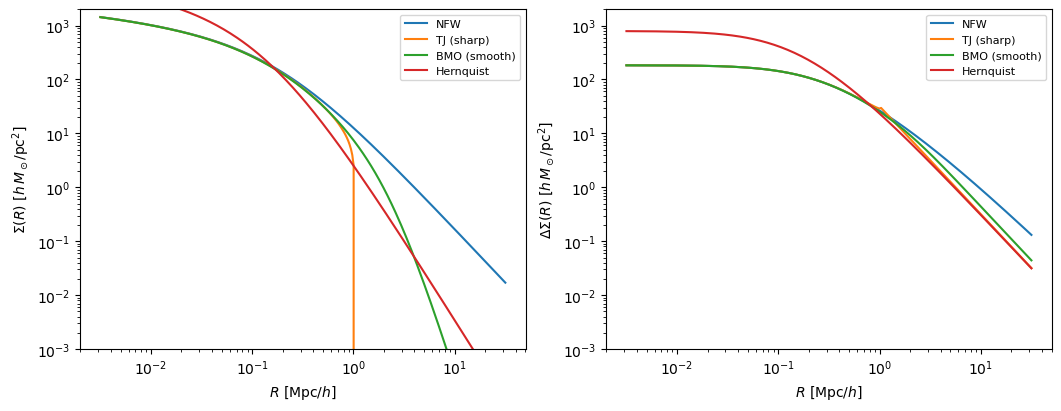

In [4]:
R = jnp.logspace(-2.5, 1.5, 300)
sig = {"NFW": nfw_sigma(R, rho_s, r_s),
       "TJ (sharp)": tnfw_sigma(R, rho_s, r_s, c),
       "BMO (smooth)": bmo_sigma(R, rho_s, r_s, tau),
       "Hernquist": hernquist_sigma(R, m_hern, rb_hern)}
dsig = {"NFW": nfw_delta_sigma(R, rho_s, r_s),
        "TJ (sharp)": tnfw_delta_sigma(R, rho_s, r_s, c),
        "BMO (smooth)": bmo_delta_sigma(R, rho_s, r_s, tau),
        "Hernquist": hernquist_delta_sigma(R, m_hern, rb_hern)}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)
for name in sig:
    axes[0].loglog(R, sig[name] * PC2, label=name)
    axes[1].loglog(R, dsig[name] * PC2, label=name)
axes[0].set_ylabel(r"$\Sigma(R)$ [$h\,M_\odot/{\rm pc}^2$]")
axes[1].set_ylabel(r"$\Delta\Sigma(R)$ [$h\,M_\odot/{\rm pc}^2$]")
for ax in axes:
    ax.set_xlabel(r"$R$ [Mpc/$h$]"); ax.set_ylim(1e-3, 2e3); ax.legend(fontsize=8)
plt.show()

### Mass budget consistency check

The projected mass in a cylinder, $M_{\rm 2D}(<R)=\pi R^2\,\bar\Sigma(<R)$,
must converge to the total 3-D mass of a *finite* profile. This is a stringent
test of the analytic $\bar\Sigma$ kernels:

* **TJ** $\to M_{\rm vir}$ (dotted at 1): all mass is inside $r_{\rm vir}$;
* **BMO** $\to m_{\rm bmo}(\tau)/m_{\rm nfw}(c)\times M_{\rm vir}\approx1.34\,M_{\rm vir}$
  for $\tau=2.5c$ (the smooth roll-off adds mass between $r_{\rm vir}$ and
  $r_t$; second dotted line, from [`bmo_mass_total`](../hod_mod/core/lensing_profiles.py));
* **NFW** diverges logarithmically — its projected mass never converges;
* **Hernquist** $\to M$ (its defining total mass).


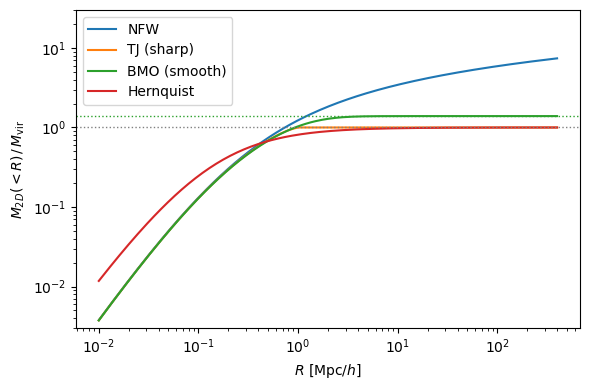

In [5]:
from hod_mod.core.halo_profiles import nfw_mean_sigma
from hod_mod.core.lensing_profiles import tnfw_mean_sigma, bmo_mean_sigma

R = jnp.logspace(-2, 2.6, 200)
m2d = {"NFW": np.pi * R**2 * nfw_mean_sigma(R, rho_s, r_s),
       "TJ (sharp)": np.pi * R**2 * tnfw_mean_sigma(R, rho_s, r_s, c),
       "BMO (smooth)": np.pi * R**2 * bmo_mean_sigma(R, rho_s, r_s, tau),
       "Hernquist": np.pi * R**2 * hernquist_mean_sigma(R, m_hern, rb_hern)}
plt.figure(figsize=(6, 4))
for name, y in m2d.items():
    plt.loglog(R, y / m_h, label=name)
plt.axhline(1.0, color="gray", ls=":", lw=1)
plt.axhline(float(bmo_mass_total(rho_s, r_s, tau)) / m_h, color="tab:green", ls=":", lw=1)
plt.xlabel(r"$R$ [Mpc/$h$]"); plt.ylabel(r"$M_{2D}(<R)\,/\,M_{\rm vir}$")
plt.ylim(3e-3, 30); plt.legend(); plt.tight_layout(); plt.show()

## 2. Weak lensing

### 2.1 Critical surface density

$\Sigma_{\rm crit}$ converts a physical surface density into a convergence. Using
the flat-space angular-diameter distances $D_l=\chi_l/(1+z_l)$,
$D_s=\chi_s/(1+z_s)$, $D_{ls}=(\chi_s-\chi_l)/(1+z_s)$ (with $\chi$ the comoving
distance from [`comoving_distance`](../hod_mod/core/distances.py)):

$$
\Sigma_{\rm crit}=\frac{c^2}{4\pi G}\,\frac{D_s}{D_l D_{ls}}
\;\xrightarrow{\text{comoving}}\;\times(1+z_l)^{-2}.
$$

Implemented in [`sigma_crit`](../hod_mod/observables/lensing.py). Two features:
it **diverges as $z_s\to z_l$** (a source just behind the lens is barely
deflected, so an enormous $\Sigma$ is needed to lens it), and it returns
$\infty$ (hence $\kappa=0$) for $z_s\le z_l$. We use the *comoving* convention
throughout; because both $\Sigma$ and $\Sigma_{\rm crit}$ pick up the same
$(1+z_l)^{-2}$ factor, the convergence $\kappa=\Sigma/\Sigma_{\rm crit}$ is
identical to the physical-convention result — the choice only has to be
consistent.


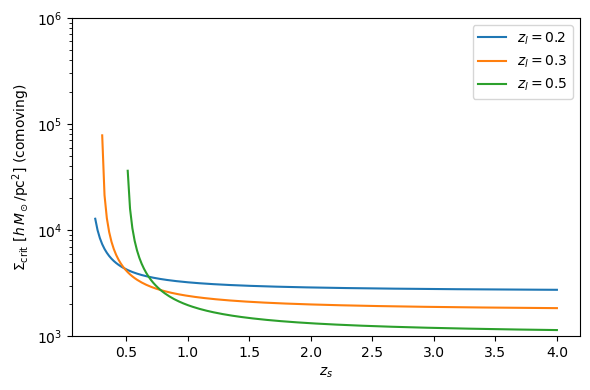

In [6]:
zs_grid = jnp.linspace(0.25, 4.0, 200)
plt.figure(figsize=(6, 4))
for zl in (0.2, 0.3, 0.5):
    sc = sigma_crit(zl, zs_grid, theta, comoving=True)
    plt.semilogy(zs_grid, sc * PC2, label=f"$z_l = {zl}$")
plt.xlabel(r"$z_s$"); plt.ylabel(r"$\Sigma_{\rm crit}$ [$h\,M_\odot/{\rm pc}^2$] (comoving)")
plt.ylim(1e3, 1e6); plt.legend(); plt.tight_layout(); plt.show()

### 2.2 The stacked-cluster $\Delta\Sigma$ model

Real cluster lensing is measured by *stacking* many clusters, which introduces
two effects beyond the single-halo $\Delta\Sigma$:

1. **Mis-centering.** The assumed centre (e.g. the brightest cluster galaxy or
   an X-ray/richness peak) is offset from the true mass centre. A cluster whose
   centre is displaced by $\mathbf R_{\rm off}$ contributes the
   azimuthally-averaged profile

   $$
   \Sigma_{\rm off}(R\mid R_{\rm off})=\frac{1}{2\pi}\int_0^{2\pi}
     \Sigma\!\left(\sqrt{R^2+R_{\rm off}^2+2RR_{\rm off}\cos\phi}\right)\mathrm d\phi .
   $$

   For a 2-D Gaussian centring error of per-axis width $\sigma_{\rm off}$, the
   *modulus* $R_{\rm off}$ follows a **Rayleigh** distribution
   $P(R_{\rm off})=(R_{\rm off}/\sigma_{\rm off}^2)\,e^{-R_{\rm off}^2/2\sigma_{\rm off}^2}$,
   over which $\Sigma_{\rm off}$ is averaged. `hod_mod` evaluates both integrals
   by Gauss–Legendre quadrature directly on the analytic $\Sigma$
   ([`offset_sigma`](../hod_mod/observables/lensing.py),
   [`offset_sigma_gaussian`](../hod_mod/observables/lensing.py)) — no Fourier
   round-trip, so it is exact at $R\ll R_{\rm off}$ where the reference's
   FFTLog Hankel transform rings.

2. **The 2-halo term.** The halo sits in an overdense region; the surrounding
   large-scale structure adds
   $\Sigma_{2h}(R)=\bar\rho_m\,b(M,z)\int\xi_{\rm lin}(\sqrt{R^2+\ell^2},z)\,\mathrm d\ell$,
   with $\xi_{\rm lin}=D^2(z)\,\xi_{\rm lin}(r,0)$ the linear matter correlation
   function and $b(M,z)$ the Tinker et al. 2010 halo bias
   ([`sigma_2h`](../hod_mod/observables/lensing.py)). It dominates beyond a few
   $\mathrm{Mpc}/h$.

The full model combines them,

$$
\Delta\Sigma_{\rm tot}=f_{\rm cen}\,\Delta\Sigma_{\rm 1h}
   +(1-f_{\rm cen})\,\Delta\Sigma_{\rm off}
   +\Delta\Sigma_{2h},
$$

with $f_{\rm cen}$ the well-centred fraction
([`ClusterLensingPrediction.delta_sigma_total`](../hod_mod/observables/lensing.py)).
This is exactly the model of Oguri et al. 2026. The decomposition below uses
$f_{\rm cen}=0.7$, $\sigma_{\rm off}=0.4\,\mathrm{Mpc}/h$: mis-centering
suppresses the signal on the $\sim\sigma_{\rm off}$ scale, the 2-halo term lifts
the large-scale tail.


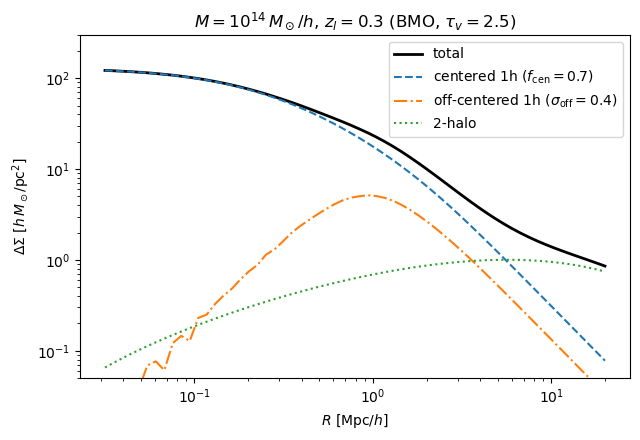

In [7]:
R = jnp.logspace(-1.5, 1.3, 60)
m14, f_cen, s_off = 1e14, 0.7, 0.4

ds_cen = clp_bmo.delta_sigma_1h(R, m14, z_l, theta)
ds_off = clp_bmo.delta_sigma_off(R, m14, z_l, theta, sigma_off=s_off)
ds_2h  = clp_bmo.delta_sigma_2h(R, m14, z_l, theta)
ds_tot = f_cen * ds_cen + (1 - f_cen) * ds_off + ds_2h

plt.figure(figsize=(6.5, 4.5))
plt.loglog(R, ds_tot * PC2, "k-", lw=2, label="total")
plt.loglog(R, f_cen * ds_cen * PC2, "--", label=f"centered 1h ($f_{{\\rm cen}}={f_cen}$)")
plt.loglog(R, (1 - f_cen) * ds_off * PC2, "-.", label=f"off-centered 1h ($\\sigma_{{\\rm off}}={s_off}$)")
plt.loglog(R, ds_2h * PC2, ":", label="2-halo")
plt.xlabel(r"$R$ [Mpc/$h$]"); plt.ylabel(r"$\Delta\Sigma$ [$h\,M_\odot/{\rm pc}^2$]")
plt.title(r"$M = 10^{14}\,M_\odot/h$, $z_l = 0.3$ (BMO, $\tau_v = 2.5$)")
plt.ylim(0.05, 300); plt.legend(); plt.tight_layout(); plt.show()

### 2.3 Tangential shear

The directly measured quantity is the tangential shear
$\gamma_t(R)=\Delta\Sigma_{\rm tot}(R)/\Sigma_{\rm crit}(z_l,z_s)$
([`ClusterLensingPrediction.gamma_t`](../hod_mod/observables/lensing.py)). For
sources at $z_s=1$ it is a few $\times10^{-2}$ on arcminute scales — the
canonical weak-lensing regime, where shapes are distorted at the percent level
and only a statistical average over many sources reveals the signal.


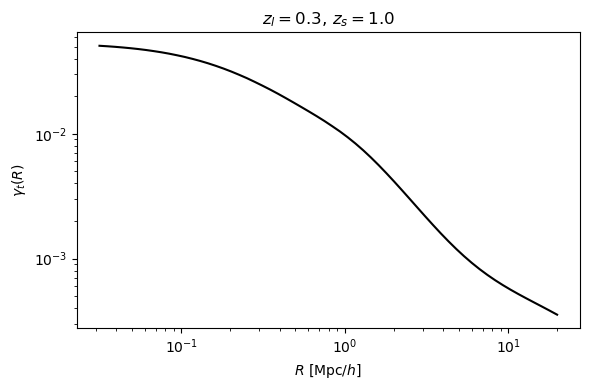

In [8]:
# tangential shear for sources at z_s = 1
gt = clp_bmo.gamma_t(R, m14, z_l, z_s, theta, f_cen=f_cen, sigma_off=s_off)
plt.figure(figsize=(6, 4))
plt.loglog(R, gt, "k-")
plt.xlabel(r"$R$ [Mpc/$h$]"); plt.ylabel(r"$\gamma_t(R)$")
plt.title(f"$z_l = {z_l}$, $z_s = {z_s}$"); plt.tight_layout(); plt.show()

### 2.4 Mis-centering, in detail

Two limiting descriptions of the centring error. **Left:** a *fixed* offset
$R_{\rm off}$ (delta-function PDF) — the profile is flattened into a core of
size $\sim R_{\rm off}$, since a ring of radius $R<R_{\rm off}$ samples the
steep inner profile from the side. **Right:** a *Gaussian* centring-error
distribution of width $\sigma_{\rm off}$ (the realistic case), which smooths the
transition. In both cases the inner $\Sigma$ is suppressed while the profile
outside $\sim R_{\rm off}$ is essentially unchanged.


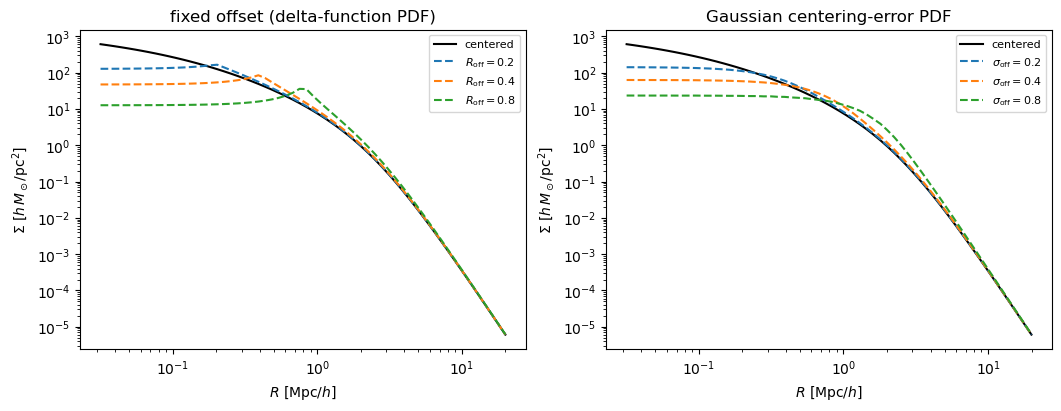

In [9]:
# mis-centering deep dive: fixed offset vs Gaussian PDF
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)
sig_cen = clp_bmo.sigma_1h(R, m14, z_l, theta)
axes[0].loglog(R, sig_cen * PC2, "k-", label="centered")
for r_off in (0.2, 0.4, 0.8):
    s = clp_bmo.sigma_off(R, m14, z_l, theta, r_off=r_off)
    axes[0].loglog(R, s * PC2, "--", label=f"$R_{{\\rm off}} = {r_off}$")
axes[1].loglog(R, sig_cen * PC2, "k-", label="centered")
for s_o in (0.2, 0.4, 0.8):
    s = clp_bmo.sigma_off(R, m14, z_l, theta, sigma_off=s_o)
    axes[1].loglog(R, s * PC2, "--", label=f"$\\sigma_{{\\rm off}} = {s_o}$")
axes[0].set_title("fixed offset (delta-function PDF)")
axes[1].set_title("Gaussian centering-error PDF")
for ax in axes:
    ax.set_xlabel(r"$R$ [Mpc/$h$]")
    ax.set_ylabel(r"$\Sigma$ [$h\,M_\odot/{\rm pc}^2$]"); ax.legend(fontsize=8)
plt.show()

## 3. Strong lensing

When the surface density is high enough the lens produces multiple images. The
governing relation is the **lens equation** mapping a source angle $\beta$ to
image angles $\theta$,

$$
\beta = \theta - \alpha(\theta),
$$

where for a circularly symmetric lens the (reduced) **deflection angle** is the
enclosed-convergence average

$$
\alpha(\theta)=\frac{2}{\theta}\int_0^\theta\kappa(\theta')\,\theta'\,\mathrm d\theta'
             =\theta\,\bar\kappa(\theta).
$$

Angles are related to projected radius by $\theta=R_{\rm com}/\chi_l$ (in
$h$-units, $\theta=R_{\rm com}/(h\chi_l)$), implemented in
[`ClusterLensingPrediction.arcsec_per_mpc`](../hod_mod/observables/lensing.py).

**Einstein radius.** A source directly behind the lens ($\beta=0$) is imaged
into a ring of radius $\theta_E$ solving $\alpha(\theta_E)=\theta_E$, i.e.

$$
\boxed{\;\bar\kappa(\theta_E)=1\;}
$$

Since $\bar\kappa$ decreases monotonically, this has a solution only if the
central $\bar\kappa$ exceeds 1 — the **strong-lensing threshold**.

**Magnification and critical curves.** The image distortion is the Jacobian
$\partial\beta/\partial\theta$, whose eigenvalues (tangential, radial) for an
axisymmetric lens are

$$
\lambda_t=1-\bar\kappa,\qquad
\lambda_r=1+\bar\kappa-2\kappa,\qquad
\mu=\frac{1}{\lambda_t\lambda_r}=\frac{1}{(1-\bar\kappa)(1+\bar\kappa-2\kappa)} .
$$

The **critical curves** are where $\mu\to\infty$: the *tangential* critical
curve $\lambda_t=0$ is exactly the Einstein ring $\bar\kappa=1$; the *radial*
critical curve $\lambda_r=0$ lies further in and bounds the region of radially
stretched images. See
[`magnification`](../hod_mod/observables/lensing.py),
[`solve_einstein_radius`](../hod_mod/observables/lensing.py),
[`radial_critical_radius`](../hod_mod/observables/lensing.py).

The plot below shows $\kappa$ (solid) and $\bar\kappa$ (dashed) for three
masses; a halo is a strong lens where its $\bar\kappa$ crosses 1 (grey line).


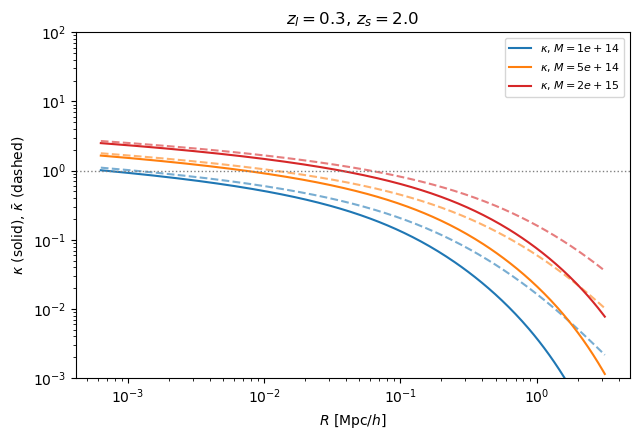

In [10]:
m15, zs_sl = 1e15, 2.0
R = jnp.logspace(-3.2, 0.5, 300)
plt.figure(figsize=(6.5, 4.5))
for m, col in zip((1e14, 5e14, 2e15), ("C0", "C1", "C3")):
    kap = clp_bmo.kappa(R, m, z_l, zs_sl, theta)
    kbar = clp_bmo.mean_kappa(R, m, z_l, zs_sl, theta)
    plt.loglog(R, kap, col + "-", label=f"$\\kappa$, $M = {m:.0e}$")
    plt.loglog(R, kbar, col + "--", alpha=0.6)
plt.axhline(1, color="gray", ls=":", lw=1)
plt.xlabel(r"$R$ [Mpc/$h$]"); plt.ylabel(r"$\kappa$ (solid), $\bar\kappa$ (dashed)")
plt.title(f"$z_l = {z_l}$, $z_s = {zs_sl}$"); plt.ylim(1e-3, 100)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3.1 Einstein radius vs mass and source redshift

$\theta_E$ grows with lens mass (more mass, larger $\bar\kappa=1$ contour) and
returns `NaN` below the strong-lensing threshold — the solver
[`solve_einstein_radius`](../hod_mod/observables/lensing.py) reports no root
where $\bar\kappa<1$ everywhere. For a $10^{15}\,M_\odot/h$ cluster at $z_l=0.3$,
$\theta_E$ reaches tens of arcseconds — the scale of observed giant arcs.
`jax.vmap` maps the (bisection-based) solver over the mass grid in one call.


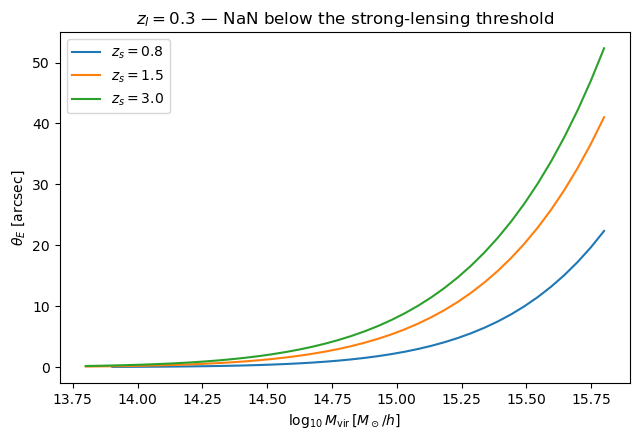

In [11]:
# Einstein radius vs mass (vmapped bisection) for several source redshifts
logM = jnp.linspace(13.8, 15.8, 40)
plt.figure(figsize=(6.5, 4.5))
for zs_i in (0.8, 1.5, 3.0):
    theta_E = jax.vmap(lambda lm: clp_bmo.einstein_radius(10.0**lm, z_l, zs_i, theta)[1])(logM)
    plt.plot(logM, theta_E, label=f"$z_s = {zs_i}$")
plt.xlabel(r"$\log_{10} M_{\rm vir}\,[M_\odot/h]$")
plt.ylabel(r"$\theta_E$ [arcsec]")
plt.title(f"$z_l = {z_l}$ — NaN below the strong-lensing threshold")
plt.legend(); plt.tight_layout(); plt.show()

The dependence on source redshift is purely geometric: at fixed lens
$\theta_E^2\propto D_{ls}/D_s$, which grows and saturates as $z_s$ increases
(a more distant source has a larger lever arm behind the lens).


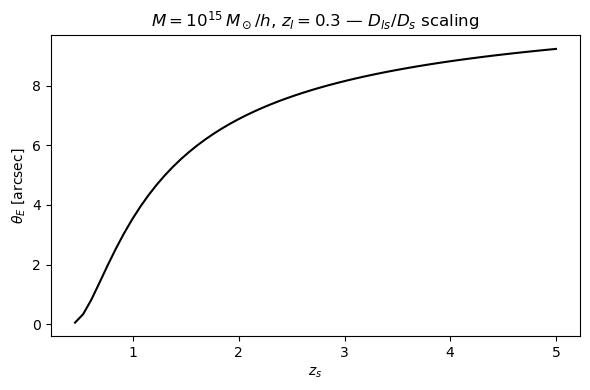

In [12]:
# geometric scaling of theta_E with source redshift at fixed mass
zs_grid = jnp.linspace(0.45, 5.0, 60)
theta_E = jax.vmap(lambda zz: clp_bmo.einstein_radius(m15, z_l, zz, theta)[1])(zs_grid)
plt.figure(figsize=(6, 4))
plt.plot(zs_grid, theta_E, "k-")
plt.xlabel(r"$z_s$"); plt.ylabel(r"$\theta_E$ [arcsec]")
plt.title(r"$M = 10^{15}\,M_\odot/h$, $z_l = 0.3$ — $D_{ls}/D_s$ scaling")
plt.tight_layout(); plt.show()

### 3.2 The deflection curve

Plotting $\alpha(\theta)$ against $\theta$ turns the Einstein-radius condition
$\alpha(\theta_E)=\theta_E$ into a simple intersection with the identity line
(the graphical solution of the lens equation for $\beta=0$).


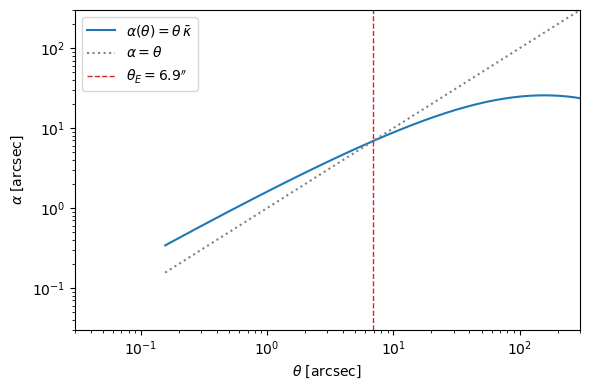

In [13]:
# deflection diagram: the Einstein radius is the alpha(theta) = theta intersection
arc = clp_bmo.arcsec_per_mpc(z_l, theta)
theta_arcsec = R * arc
alpha = clp_bmo.deflection(R, m15, z_l, zs_sl, theta)
r_E, t_E = clp_bmo.einstein_radius(m15, z_l, zs_sl, theta)

plt.figure(figsize=(6, 4))
plt.loglog(theta_arcsec, alpha, "C0-", label=r"$\alpha(\theta) = \theta\,\bar\kappa$")
plt.loglog(theta_arcsec, theta_arcsec, "gray", ls=":", label=r"$\alpha = \theta$")
plt.axvline(float(t_E), color="C3", ls="--", lw=1, label=f"$\\theta_E = {float(t_E):.1f}''$")
plt.xlabel(r"$\theta$ [arcsec]"); plt.ylabel(r"$\alpha$ [arcsec]")
plt.xlim(0.03, 300); plt.ylim(0.03, 300); plt.legend(); plt.tight_layout(); plt.show()

### 3.3 Magnification and critical curves

$|\mu(\theta)|$ diverges on both critical curves: the tangential one at
$\theta_E$ (where $\bar\kappa=1$) and the radial one further in (where
$1+\bar\kappa-2\kappa=0$). Between them images are highly magnified; a real
extended source straddling the tangential curve is stretched into a giant arc.


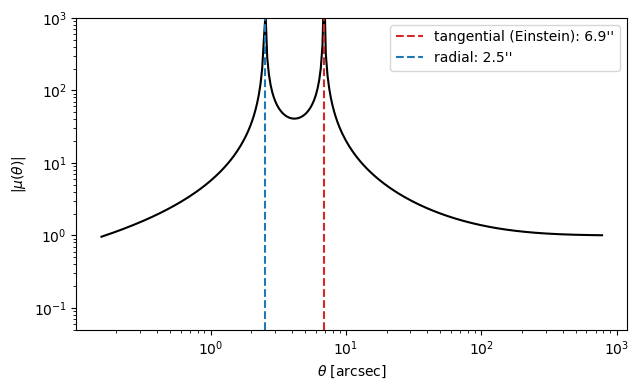

In [14]:
# magnification with both critical curves
r_tan, r_rad = clp_bmo.critical_curves(m15, z_l, zs_sl, theta)
mu = clp_bmo.magnification(R, m15, z_l, zs_sl, theta)
plt.figure(figsize=(6.5, 4))
plt.loglog(R * arc, jnp.abs(mu), "k-")
plt.axvline(float(r_tan) * float(arc), color="C3", ls="--",
            label=f"tangential (Einstein): {float(r_tan)*float(arc):.1f}''")
plt.axvline(float(r_rad) * float(arc), color="C0", ls="--",
            label=f"radial: {float(r_rad)*float(arc):.1f}''")
plt.xlabel(r"$\theta$ [arcsec]"); plt.ylabel(r"$|\mu(\theta)|$")
plt.ylim(0.05, 1e3); plt.legend(); plt.tight_layout(); plt.show()

### 3.4 Differentiability — the point of the JAX port

Every observable, *including the root-found Einstein radius*, is
differentiable. This is not automatic: $\theta_E$ is defined implicitly by
$\bar\kappa(\theta_E,p)=1$ for parameters $p$, and naively differentiating a
bisection loop gives a wrong (or zero) gradient. The implicit function theorem
gives the exact derivative

$$
\frac{\mathrm d\theta_E}{\mathrm dp}
   =-\frac{\partial\bar\kappa/\partial p}{\partial\bar\kappa/\partial\theta}
   \Bigg|_{\theta_E}.
$$

[`solve_einstein_radius`](../hod_mod/observables/lensing.py) obtains the *value*
by bisection but detaches it (`stop_gradient`) and adds a single Newton step;
the Newton step is a no-op on the value (already converged) but attaches exactly
this implicit-function gradient. The cell below reads off
$\mathrm d\theta_E/\mathrm d\log M$, $\mathrm d\theta_E/\mathrm d\Omega_m$ and
$\mathrm d\Delta\Sigma/\mathrm d\log M$ with `jax.grad` — the raw material for
Fisher forecasts and gradient-based inference.


In [15]:
dtE_dlogM = jax.grad(lambda lm: clp_bmo.einstein_radius(10.0**lm, z_l, zs_sl, theta)[1])(15.0)
dtE_dOm = jax.grad(
    lambda om: clp_bmo.einstein_radius(m15, z_l, zs_sl, {**theta, "Omega_m": om})[1]
)(theta["Omega_m"])
dds_dlogM = jax.grad(
    lambda lm: clp_bmo.delta_sigma_1h(jnp.array([1.0]), 10.0**lm, z_l, theta)[0] * PC2)(15.0)
print(f"d theta_E / d log10 M   = {float(dtE_dlogM):+.3f} arcsec/dex")
print(f"d theta_E / d Omega_m   = {float(dtE_dOm):+.3f} arcsec")
print(f"d DeltaSigma(1 Mpc/h) / d log10 M = {float(dds_dlogM):+.3f} (h Msun/pc^2)/dex")

d theta_E / d log10 M   = +18.495 arcsec/dex
d theta_E / d Omega_m   = +17.329 arcsec
d DeltaSigma(1 Mpc/h) / d log10 M = +156.767 (h Msun/pc^2)/dex


## 4. Galaxy-scale composite lens: Hernquist stars + halo

Convergence adds linearly ($\kappa_{\rm tot}=\sum_i\kappa_i$), so a lens with a
concentrated stellar component embedded in a dark halo is just the sum of the
two $\bar\kappa$ profiles. This is the galaxy–galaxy strong-lensing regime: a
massive elliptical, modelled as a Hernquist stellar profile
($M_*=2\times10^{11}\,M_\odot/h$, $r_e=7\,\mathrm{kpc}/h$) inside a
$10^{13}\,M_\odot/h$ halo.

Because [`solve_einstein_radius`](../hod_mod/observables/lensing.py) accepts a
bare $\bar\kappa$ callable, a composite lens needs no new code — we pass
$\bar\kappa_{\rm halo}+\bar\kappa_{\rm stars}$. (The `_kappa_fns` helper returns
the $(\kappa,\bar\kappa)$ closures the strong-lensing solvers consume.)


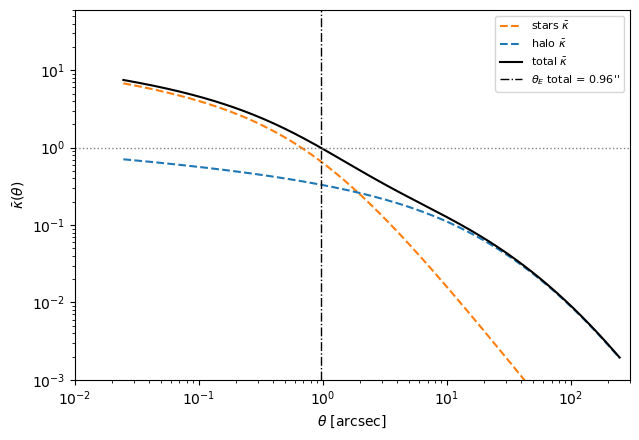

theta_E: stars only = 0.672'', halo only = nan, total = 0.962''
radial critical curve (total) = 0.266''


In [16]:
from hod_mod.core.lensing_profiles import HERNQUIST_RB_RE

m_star, r_e = 2e11, 0.007
r_b = HERNQUIST_RB_RE * r_e
m_halo, z_gal, zs_gal = 1e13, 0.3, 1.5

isc = float(inv_sigma_crit(z_gal, zs_gal, theta))
_, kbar_halo = clp_bmo._kappa_fns(m_halo, z_gal, zs_gal, theta)
kap_halo, _ = clp_bmo._kappa_fns(m_halo, z_gal, zs_gal, theta)

from hod_mod.core.lensing_profiles import hernquist_sigma as h_sig
kbar_star = lambda r: jnp.squeeze(hernquist_mean_sigma(jnp.atleast_1d(r), m_star, r_b)) * isc
kap_star  = lambda r: jnp.squeeze(h_sig(jnp.atleast_1d(r), m_star, r_b)) * isc
kbar_tot  = lambda r: kbar_halo(r) + kbar_star(r)
kap_tot   = lambda r: kap_halo(r) + kap_star(r)

R = jnp.logspace(-4, 0, 300)
arc_gal = clp_bmo.arcsec_per_mpc(z_gal, theta)
plt.figure(figsize=(6.5, 4.5))
plt.loglog(R * arc_gal, jax.vmap(kbar_star)(R), "C1--", label=r"stars $\bar\kappa$")
plt.loglog(R * arc_gal, jax.vmap(kbar_halo)(R), "C0--", label=r"halo $\bar\kappa$")
plt.loglog(R * arc_gal, jax.vmap(kbar_tot)(R), "k-", label=r"total $\bar\kappa$")
plt.axhline(1, color="gray", ls=":", lw=1)

tE_star = float(solve_einstein_radius(kbar_star)) * float(arc_gal)
tE_tot  = float(solve_einstein_radius(kbar_tot)) * float(arc_gal)
tE_halo = float(solve_einstein_radius(kbar_halo)) * float(arc_gal)
rr_tot  = float(radial_critical_radius(kap_tot, kbar_tot)) * float(arc_gal)
plt.axvline(tE_tot, color="k", ls="-.", lw=1, label=f"$\\theta_E$ total = {tE_tot:.2f}''")
plt.xlabel(r"$\theta$ [arcsec]"); plt.ylabel(r"$\bar\kappa(\theta)$")
plt.xlim(1e-2, 300); plt.ylim(1e-3, 60); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"theta_E: stars only = {tE_star:.3f}'', halo only = {tE_halo}, total = {tE_tot:.3f}''")
print(f"radial critical curve (total) = {rr_tot:.3f}''")

The halo alone is **sub-critical** ($\theta_E=$ `nan`, its $\bar\kappa$
never reaches 1): a $10^{13}\,M_\odot/h$ halo does not strong-lens on its own.
The concentrated stellar Hernquist component pushes the central $\bar\kappa$
above 1 and makes the galaxy a strong lens; the halo then *boosts* $\theta_E$
beyond the stars-only value by adding mass inside the Einstein radius. This is
why galaxy-scale strong lenses constrain the stellar-plus-dark mass within a
few kpc — the classic result of systems like SLACS.


### Does truncation matter?

A closing sanity check contrasting the three cluster profiles. The Einstein
radius is set by the mass *inside* $\sim\theta_E$ (deep in the halo, far from the
truncation), so it barely moves between NFW/BMO/TJ. $\Delta\Sigma$ at the
outskirts, by contrast, is a direct probe of the truncation and differs by tens
of percent — which is precisely why weak lensing at large radius, not strong
lensing, is the tool to measure the outer profile and the 1-halo/2-halo
transition.


In [17]:
# does truncation matter for theta_E?  (cluster scale)
tE = {}
for name, clp_i in [("NFW (infinite)", clp_nfw), ("BMO tau_v=2.5", clp_bmo),
                    ("TJ tau_v=1", clp_tj)]:
    tE[name] = float(clp_i.einstein_radius(m15, z_l, zs_sl, theta)[1])
ds1 = {name: float(clp_i.delta_sigma_1h(jnp.array([5.0]), m15, z_l, theta)[0] * PC2)
       for name, clp_i in [("NFW (infinite)", clp_nfw), ("BMO tau_v=2.5", clp_bmo),
                           ("TJ tau_v=1", clp_tj)]}
print("theta_E [arcsec]          :", {k: round(v, 3) for k, v in tE.items()})
print("DeltaSigma(5 Mpc/h) [pc^2]:", {k: round(v, 3) for k, v in ds1.items()})
print("-> truncation shifts theta_E by only a few percent (inner halo),")
print("   but DeltaSigma at the outskirts by tens of percent.")

theta_E [arcsec]          : {'NFW (infinite)': 7.074, 'BMO tau_v=2.5': 6.879, 'TJ tau_v=1': 6.907}
DeltaSigma(5 Mpc/h) [pc^2]: {'NFW (infinite)': 19.64, 'BMO tau_v=2.5': 15.908, 'TJ tau_v=1': 12.732}
-> truncation shifts theta_E by only a few percent (inner halo),
   but DeltaSigma at the outskirts by tens of percent.


## Summary and references

**Code.** Two modules, pure JAX with NaN-free gradients across every analytic
branch point:

* [`hod_mod/core/lensing_profiles.py`](../hod_mod/core/lensing_profiles.py) —
  $\rho$, $M(<r)$, $\Sigma$, $\bar\Sigma$, $\Delta\Sigma$, $\hat u(k)$ for the
  sharply (TJ) and smoothly (BMO) truncated NFW and the Hernquist profile;
* [`hod_mod/observables/lensing.py`](../hod_mod/observables/lensing.py) —
  $\Sigma_{\rm crit}$, $\kappa$, $\gamma_t$, mis-centering, 2-halo term, and the
  strong-lensing block (deflection, Einstein radius, magnification, critical
  curves), all wrapped by `ClusterLensingPrediction`.

Validated against the reference implementation and the closed forms in
[`tests/test_lensing_profiles.py`](../tests/test_lensing_profiles.py) and
[`tests/test_lensing_observables.py`](../tests/test_lensing_observables.py); the
total mis-centred $\Delta\Sigma$ agrees with the reference FFTLog pipeline to
$\sim1\%$ (max) / $0.04\%$ (median). See also
[`docs/lensing.rst`](../docs/lensing.rst).

**Literature.**

* Oguri et al. 2026, PASJ 78, 416 — [arXiv:2512.13954](https://arxiv.org/abs/2512.13954) (HSC cluster catalogs; the model this ports)
* Reference code — [`github.com/massarin/halo_lensing`](https://github.com/massarin/halo_lensing)
* Navarro, Frenk & White 1997, ApJ 490, 493 — NFW profile
* Wright & Brainerd 2000, ApJ 534, 34 — NFW projected $\Sigma$, $\Delta\Sigma$
* Takada & Jain 2003, MNRAS 340, 580 — sharply truncated NFW projection
* Baltz, Marshall & Oguri 2009, JCAP 01, 015; Oguri & Hamana 2011, MNRAS 414, 1851 — BMO profile and its lensing forms
* Hernquist 1990, ApJ 356, 359 — Hernquist profile
* Bartelmann & Schneider 2001, Phys. Rep. 340, 291 — lensing formalism
* Tinker et al. 2010, ApJ 724, 878 — halo bias; Eisenstein & Hu 1998, ApJ 496, 605 — transfer function
